# Forecast Harga Beras dan Early Warning System

Notebook ini menjelaskan proses prediksi harga beras 7 hari ke depan
menggunakan model XGBoost serta implementasi sistem peringatan dini
terhadap potensi lonjakan harga.

Komponen yang ditampilkan:
- Prediksi harga
- Grafik tren harga
- Monitoring performa model
- Indikator risiko kenaikan harga

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load data historis

In [3]:
hist = pd.read_csv("../data/processed/harga_features.csv")

hist["Tanggal"] = pd.to_datetime(hist["Tanggal"])

hist.head()

,Tanggal,Provinsi,Komoditas,Nilai,NilaiDiff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2024-03-01,Sulawesi Tengah,Beras,15650.0,Rp0,14800.0,13800.0,14778.571429,748.251931
1,2024-03-01,Jambi,Beras,14800.0,Rp0,15650.0,15850.0,14628.571429,585.133277
2,2024-03-01,DI Yogyakarta,Beras,15400.0,Rp0,14800.0,13850.0,14850.000000,532.290647
3,2024-03-01,Jawa Timur,Beras,15400.0,Rp0,15400.0,14050.0,15042.857143,428.591269
4,2024-03-01,Riau,Beras,15450.0,Rp100,15400.0,14550.0,15171.428571,389.291175


# Load hasil forecast

In [4]:
forecast = pd.read_csv("../data/processed/forecast_result.csv")

forecast["Tanggal"] = pd.to_datetime(forecast["Tanggal"])

forecast

,Tanggal,Nilai
0,2026-03-04,16055.131
1,2026-03-05,15524.943
2,2026-03-06,15524.943
3,2026-03-07,15524.943
4,2026-03-08,15524.943
5,2026-03-09,15524.943
6,2026-03-10,15524.943


# Load model metrics

In [5]:
with open("../models/model_metrics.json") as f:
    metrics = json.load(f)

metrics

{'mape': 0.026267646713445645}

In [6]:
harga_sekarang = hist["Nilai"].iloc[-1]

print("Harga saat ini:", harga_sekarang)

Harga saat ini: 19100.0


# Prediksi harga 7 hari

In [7]:
forecast

,Tanggal,Nilai
0,2026-03-04,16055.131
1,2026-03-05,15524.943
2,2026-03-06,15524.943
3,2026-03-07,15524.943
4,2026-03-08,15524.943
5,2026-03-09,15524.943
6,2026-03-10,15524.943


# Visualisasi harga historis + forecast

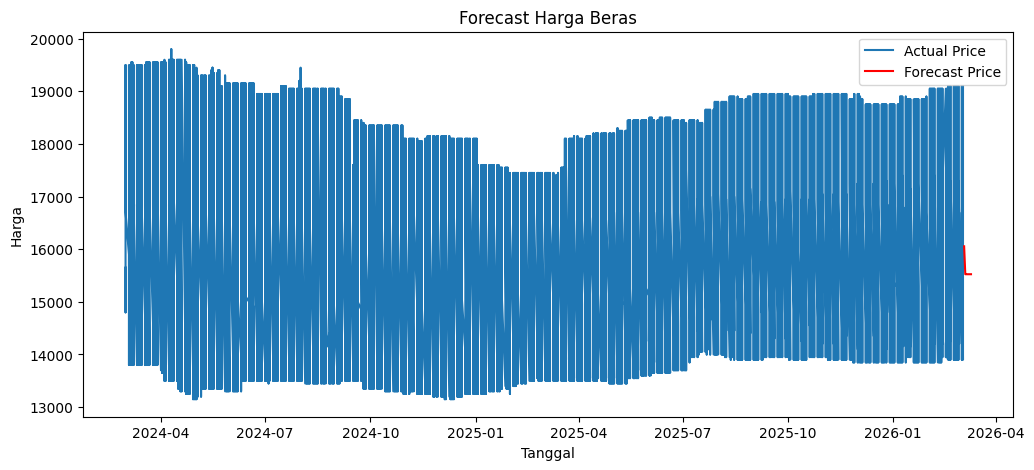

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    hist["Tanggal"],
    hist["Nilai"],
    label="Actual Price"
)

plt.plot(
    forecast["Tanggal"],
    forecast["Nilai"],
    color="red",
    label="Forecast Price"
)

plt.xlabel("Tanggal")
plt.ylabel("Harga")

plt.title("Forecast Harga Beras")

plt.legend()

plt.show()

# Logika Early Warning

In [9]:
harga_prediksi = forecast["Nilai"].iloc[-1]

price_change = (harga_prediksi - harga_sekarang) / harga_sekarang

price_change

np.float64(-0.1871757591623037)

# Interpretasi Resiko

In [10]:
if price_change > 0.05:
    print("⚠️ Potensi kenaikan harga signifikan")
else:
    print("Harga relatif stabil")

Harga relatif stabil
